In [ ]:
# ============================================================
# STEP 2 — IMAGE FEATURE EXTRACTION (EfficientNetB0 + ViT)
# For CT + US folders with train/valid/test structure
# ============================================================

import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from transformers import ViTFeatureExtractor, TFViTModel
from transformers import ViTFeatureExtractor, TFViTModel
import transformers
transformers.logging.set_verbosity_error()
# ----------------------------
# Paths to dataset
# ----------------------------
base_path = "/kaggle/input/classification-dataset1"
ct_base = os.path.join(base_path, "CT_Classification.v1i.folder/CT_Classification.v1i.folder")
us_base = os.path.join(base_path, "Ultrasound_classification.v1i.folder/Ultrasound_classification.v1i.folder")

splits = ["train", "valid", "test"]
os.makedirs("features", exist_ok=True)

# ----------------------------
# EfficientNetB0 (local features)
# ----------------------------
IMG_SIZE = (224, 224)
eff_base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
eff_out = tf.keras.layers.GlobalAveragePooling2D()(eff_base.output)
eff_model = Model(inputs=eff_base.input, outputs=eff_out)

def extract_eff_features(folder):
    image_paths, labels = [], []
    for cls in sorted(os.listdir(folder)):
        cls_dir = os.path.join(folder, cls)
        if not os.path.isdir(cls_dir):
            continue
        for f in os.listdir(cls_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(cls_dir, f))
                labels.append(cls.lower())
    feats = []
    for path in tqdm(image_paths, desc=f"EfficientNet extracting from {folder}"):
        try:
            img = tf.io.read_file(path)
            img = tf.image.decode_image(img, channels=3)
            img = tf.image.resize(img, IMG_SIZE)
            img = tf.cast(img, tf.float32) / 255.0
            feat = eff_model(tf.expand_dims(img, 0), training=False)
            feats.append(feat.numpy().squeeze())
        except Exception as e:
            print("❌ Error reading:", path, "|", e)
    return np.array(feats), np.array(labels)

# ----------------------------
# ViT (global features)
# ----------------------------
vit_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")
vit_model = TFViTModel.from_pretrained("google/vit-base-patch16-224")

def extract_vit_features(folder):
    image_paths, labels = [], []
    for cls in sorted(os.listdir(folder)):
        cls_dir = os.path.join(folder, cls)
        if not os.path.isdir(cls_dir):
            continue
        for f in os.listdir(cls_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(cls_dir, f))
                labels.append(cls.lower())
    feats = []
    for path in tqdm(image_paths, desc=f"ViT extracting from {folder}"):
        try:
            img = Image.open(path).convert("RGB").resize((224,224))
            inputs = vit_extractor(images=img, return_tensors="tf")
            outputs = vit_model(**inputs)
            cls_vec = outputs.last_hidden_state[:,0,:].numpy().squeeze()
            feats.append(cls_vec)
        except Exception as e:
            print("❌ Error reading:", path, "|", e)
    return np.array(feats), np.array(labels)

# ----------------------------
# Extract for CT and US (train/valid/test)
# ----------------------------
for split in splits:
    # CT
    ct_split = os.path.join(ct_base, split)
    if os.path.exists(ct_split):
        ct_eff, ct_lbl = extract_eff_features(ct_split)
        ct_vit, _ = extract_vit_features(ct_split)
        np.save(f"features/ct_eff_{split}.npy", ct_eff)
        np.save(f"features/ct_vit_{split}.npy", ct_vit)
        np.save(f"features/ct_labels_{split}.npy", ct_lbl)
        print(f"✅ Saved CT {split}: Eff={ct_eff.shape}, ViT={ct_vit.shape}")

    # Ultrasound
    us_split = os.path.join(us_base, split)
    if os.path.exists(us_split):
        us_eff, us_lbl = extract_eff_features(us_split)
        us_vit, _ = extract_vit_features(us_split)
        np.save(f"features/us_eff_{split}.npy", us_eff)
        np.save(f"features/us_vit_{split}.npy", us_vit)
        np.save(f"features/us_labels_{split}.npy", us_lbl)
        print(f"✅ Saved US {split}: Eff={us_eff.shape}, ViT={us_vit.shape}")

print("\n🎯 All CT + US image features extracted and saved successfully!")

2026-03-19 06:46:26.823245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773902787.184441      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773902787.338493      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

EfficientNet extracting from /kaggle/input/classification-dataset1/CT_Classification.v1i.folder/CT_Classification.v1i.folder/train:   0%|          | 0/564 [00:00<?, ?it/s]I0000 00:00:1773902830.184387      47 cuda_dnn.cc:529] Loaded cuDNN version 90300
EfficientNet extracting from /kaggle/input/classification-dataset1/CT_Classification.v1i.folder/CT_Classification.v1i.folder/train:  45%|████▍     | 251/564 [01:08<01:21,  3.82it/s]

In [1]:
# ============================================================
# STEP 1 — TABULAR FEATURE EXTRACTION  (CT + US combined)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
import os

# =========================
# 1️⃣ Load both CSV files
# =========================
us_csv = "/kaggle/input/csv-classification/Patient History_CSV_US_Combine_Classify.csv"
ct_csv = "/kaggle/input/csv-classification/patient_history_CSV_CT_Combine_Classify.csv"

us_df = pd.read_csv(us_csv)
ct_df = pd.read_csv(ct_csv)

# =========================
# 2️⃣ Standardize column names
# =========================
us_df.columns = us_df.columns.str.strip().str.lower()
ct_df.columns = ct_df.columns.str.strip().str.lower()

# Unify naming differences
us_df = us_df.rename(columns={'type of water': 'type_of_water', 'region': 'region'})
ct_df = ct_df.rename(columns={'type of water': 'type_of_water', 'region': 'region'})

# Add modality indicator
us_df['modality'] = 'us'
ct_df['modality'] = 'ct'

# =========================
# 3️⃣ Keep relevant columns
# =========================
cols = [
    'age', 'gender', 'profession', 'weight',
    'water', 'type_of_water', 'region',
    'class', 'modality'
]
us_df = us_df[cols]
ct_df = ct_df[cols]

# Merge both modalities
tab_df = pd.concat([us_df, ct_df], ignore_index=True)

# =========================
# 4️⃣ Clean missing / nulls
# =========================
tab_df = tab_df.fillna('unknown')

# Normalize label capitalization
tab_df['class'] = tab_df['class'].astype(str).str.strip().str.lower()

# =========================
# 5️⃣ Encode features
# =========================
num_cols = ['age', 'weight']
cat_cols = ['gender', 'profession', 'water', 'type_of_water', 'region', 'modality']

# Scale numeric columns
scaler = StandardScaler()
tab_df[num_cols] = scaler.fit_transform(tab_df[num_cols])

# One-hot encode categorical columns
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_features = enc.fit_transform(tab_df[cat_cols])

# Combine numeric + categorical features
X_tab = np.hstack([tab_df[num_cols].values, cat_features])

# Encode labels
le = LabelEncoder()
y_tab = le.fit_transform(tab_df['class'])

# =========================
# 6️⃣ Save processed arrays
# =========================
os.makedirs("features", exist_ok=True)
np.save("features/tabular_features.npy", X_tab)
np.save("features/labels.npy", y_tab)

# =========================
# 7️⃣ Display summary
# =========================
print("✅ Tabular features saved successfully!")
print("   features/tabular_features.npy  →", X_tab.shape)
print("   features/labels.npy            →", y_tab.shape)
print("   Label classes:", le.classes_)
print("\nClass distribution:\n", tab_df['class'].value_counts())

✅ Tabular features saved successfully!
   features/tabular_features.npy  → (2083, 680)
   features/labels.npy            → (2083,)
   Label classes: ['cyst' 'normal' 'stone' 'tumor']

Class distribution:
 class
normal    934
stone     649
cyst      400
tumor     100
Name: count, dtype: int64


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# base features folder (Kaggle default)
feat_dir = "/kaggle/working/features"

In [5]:
def load_features(modality, split):
    eff = np.load(f"{feat_dir}/{modality}eff{split}.npy")
    vit = np.load(f"{feat_dir}/{modality}vit{split}.npy")
    labels = np.load(f"{feat_dir}/{modality}labels{split}.npy", allow_pickle=True)
    return eff, vit, labels

In [7]:
import numpy as np
import os

def load_features(modality, split):
    eff = np.load(f"features/{modality}_eff_{split}.npy", allow_pickle=True)
    vit = np.load(f"features/{modality}_vit_{split}.npy", allow_pickle=True)
    lbl = np.load(f"features/{modality}_labels_{split}.npy", allow_pickle=True)
    return eff, vit, lbl


In [8]:
splits = ["train", "valid", "test"]
all_eff, all_vit, all_lbl = {}, {}, {}

for split in splits:
    eff_ct, vit_ct, lbl_ct = load_features("ct", split)
    eff_us, vit_us, lbl_us = load_features("us", split)
    all_eff[split] = np.vstack([eff_ct, eff_us])
    all_vit[split] = np.vstack([vit_ct, vit_us])
    all_lbl[split] = np.concatenate([lbl_ct, lbl_us])

for s in splits:
    print(f"{s:>5} | Eff {all_eff[s].shape} | ViT {all_vit[s].shape} | n={len(all_lbl[s])}")

train | Eff (1551, 1280) | ViT (1551, 768) | n=1551
valid | Eff (326, 1280) | ViT (326, 768) | n=326
 test | Eff (332, 1280) | ViT (332, 768) | n=332


In [9]:
X_tab = np.load(f"{feat_dir}/tabular_features.npy")
y_tab = np.load(f"{feat_dir}/labels.npy")
print("Tabular:", X_tab.shape, "Labels:", y_tab.shape)

Tabular: (2083, 680) Labels: (2083,)


In [12]:
def sample_tabular(n):
    idx = np.random.randint(0, X_tab.shape[0], n)
    return X_tab[idx]

In [13]:
le = LabelEncoder()
y_train_enc = le.fit_transform([l.lower() for l in all_lbl["train"]])
y_val_enc   = le.transform([l.lower() for l in all_lbl["valid"]])
y_test_enc  = le.transform([l.lower() for l in all_lbl["test"]])

X_train = np.concatenate([
    all_eff["train"],
    all_vit["train"],
    sample_tabular(len(y_train_enc))
], axis=1)

X_val = np.concatenate([
    all_eff["valid"],
    all_vit["valid"],
    sample_tabular(len(y_val_enc))
], axis=1)

X_test = np.concatenate([
    all_eff["test"],
    all_vit["test"],
    sample_tabular(len(y_test_enc))
], axis=1)

print("Final shapes → Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", le.classes_)

Final shapes → Train: (1551, 2728) Val: (326, 2728) Test: (332, 2728)
Classes: ['kidney_cyst' 'kidney_normal' 'kidney_stone' 'kidney_tumor']


Optimize Accuracy

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import joblib   # for saving scaler

# ----------------------------
# 1️⃣ Feature Scaling
# ----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Save scaler (IMPORTANT)
joblib.dump(scaler, "scaler.pkl")

# ----------------------------
# 2️⃣ Build Model
# ----------------------------
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train_enc))

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(num_classes, activation='softmax')
])

# ----------------------------
# 3️⃣ Compile Model
# ----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ----------------------------
# 4️⃣ Callbacks (Save Best Model in .h5)
# ----------------------------
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "kidney_best_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True
    )
]

# ----------------------------
# 5️⃣ Train Model
# ----------------------------
history = model.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------
# 6️⃣ Evaluate Model
# ----------------------------
train_loss, train_acc = model.evaluate(X_train, y_train_enc, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_enc, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=0)

print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Detailed report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred_classes))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_enc, y_pred_classes))

# ----------------------------
# 7️⃣ Save Final Model (.h5)
# ----------------------------
model.save("kidney_final_model.h5")
print("\nModel saved successfully in .h5 format ✅")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,397,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,565,060 (5.97 MB)

 Trainable params: 1,563,524 (5.96 MB)

 Non-trainable params: 1,536 (6.00 KB)

...

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7450 - loss: 0.6457 - val_accuracy: 0.6503 - val_loss: 0.8483 - learning_rate: 0.0010
Epoch 8/50
42/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7731 - loss: 0.5805
Epoch 8: val_accuracy improved from 0.65031 to 0.65644, saving model to kidney_best_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7726 - loss: 0.5841 - val_accuracy: 0.6564 - val_loss: 0.9163 - learning_rate: 0.0010
Epoch 9/50
41/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7847 - loss: 0.5613
Epoch 9: val_accuracy improved from 0.65644 to 0.66564, saving model to kidney_best_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7820 - loss: 0.5641 - val_accuracy: 0.6656 - val_loss: 0.9270 - learning_rate: 0.0010
Epoch 10/50
42/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8067 - loss: 0.4637
Epoch 10: val_accuracy did not improve from 0.66564
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8036 - loss: 0.4728 - val_accuracy: 0.6472 - val_loss: 1.0527 - learning_rate: 0.0010
Epoch 11/50
41/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8258 - loss: 0.4633
Epoch 11: val_accuracy did not improve from 0.66564
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8247 - loss: 0.4665 - val_accuracy: 0.6288 - val_loss: 0.9832 - learning_rate: 0.0010
Epoch 12/50
42/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8136 - loss: 0.4753
Epoch 12: val_accuracy improved from 0.66564 to 0.67791, saving model to kidney_best_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8145 - loss: 0.4755 - val_accuracy: 0.6779 - val_loss: 1.0649 - learning_rate: 0.0010
Epoch 13/50
43/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8270 - loss: 0.4261
Epoch 13: val_accuracy did not improve from 0.67791
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8276 - loss: 0.4250 - val_accuracy: 0.5951 - val_loss: 1.0637 - learning_rate: 0.0010
Epoch 14/50
41/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8270 - loss: 0.4142
Epoch 14: val_accuracy did not improve from 0.67791
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8261 - loss: 0.4202 - val_accuracy: 0.6196 - val_loss: 1.0555 - learning_rate: 0.0010
Epoch 15/50
40/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8511 - loss: 0.3538
Epoch 15: val_accuracy did not improve from 0.67791

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8508 - loss: 0.3555 - val_accuracy: 0.613


Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.52      0.60        61
           1       0.64      0.58      0.61       127
           2       0.55      0.70      0.62       125
           3       0.87      0.68      0.76        19

    accuracy                           0.62       332
   macro avg       0.69      0.62      0.65       332
weighted avg       0.64      0.62      0.62       332


Confusion Matrix:

[[32 12 17  0]
 [ 5 74 48  0]
 [ 7 29 87  2]
 [ 1  0  5 13]]

Model saved successfully in .h5 format ✅


In [15]:
import tensorflow as tf
import joblib

# Load model
model = tf.keras.models.load_model("kidney_final_model.h5")

# Load scaler
scaler = joblib.load("scaler.pkl")

print("Model and scaler loaded successfully ✅")

Model and scaler loaded successfully ✅


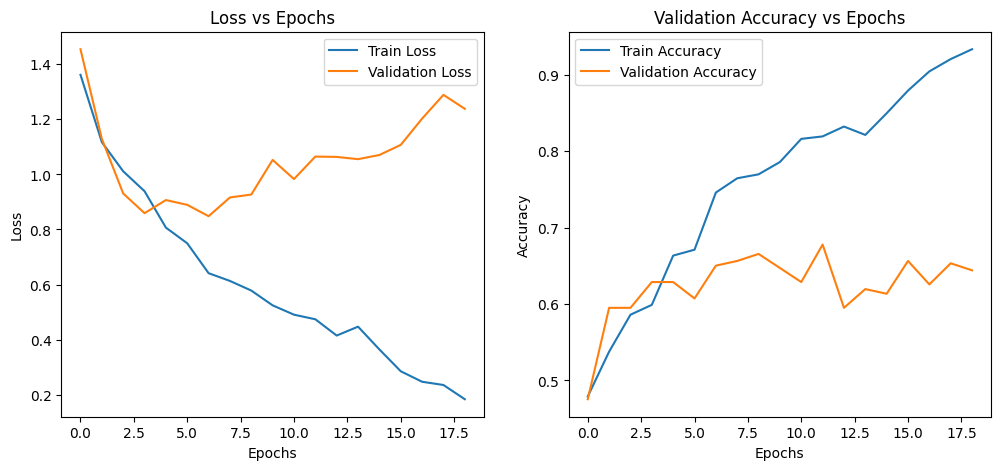

In [16]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Validation Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

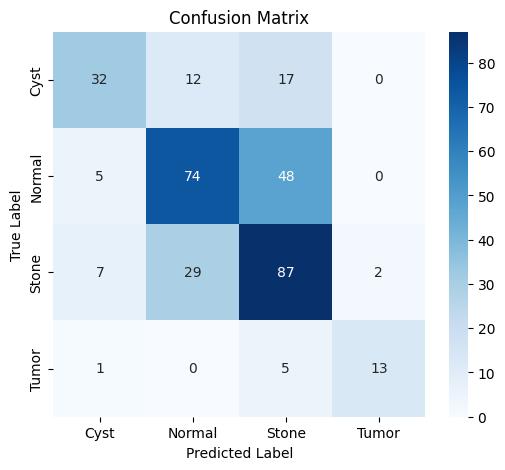

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np


plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Cyst','Normal','Stone','Tumor'],
            yticklabels=['Cyst','Normal','Stone','Tumor'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


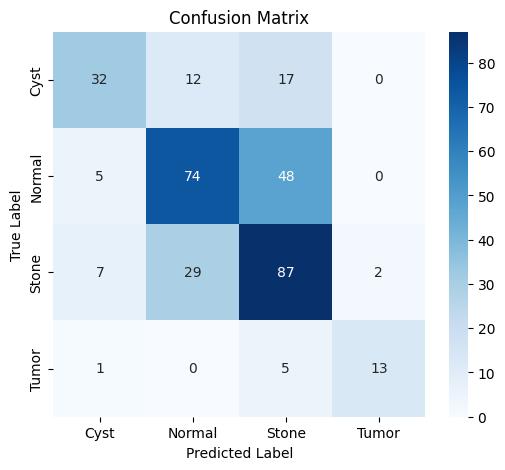

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Predict classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_classes)

# Class names (according to your CKD dataset)
class_names = ['Cyst','Normal','Stone','Tumor']

# Plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [19]:
input_dim = X_train.shape[1]
num_classes = len(le.classes_)

model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1024)           │     2,794,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457,796 (13.19 MB)

 Trainable params: 3,454,724 (13.18 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [20]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/fusion_best_model.h5",
        monitor="val_accuracy", save_best_only=True, mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=3, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3580 - loss: 1.7446

49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.3587 - loss: 1.7420 - val_accuracy: 0.5552 - val_loss: 1.0337 - learning_rate: 1.0000e-04
Epoch 2/40
38/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5345 - loss: 1.1839

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5366 - loss: 1.1765 - val_accuracy: 0.5859 - val_loss: 0.9272 - learning_rate: 1.0000e-04
Epoch 3/40
39/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5352 - loss: 1.0373

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5411 - loss: 1.0385 - val_accuracy: 0.6012 - val_loss: 0.8847 - learning_rate: 1.0000e-04
Epoch 4/40
37/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6151 - loss: 0.9874

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6150 - loss: 0.9728 - val_accuracy: 0.6288 - val_loss: 0.8335 - learning_rate: 1.0000e-04
Epoch 5/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6482 - loss: 0.8410 - val_accuracy: 0.6196 - val_loss: 0.8459 - learning_rate: 1.0000e-04
Epoch 6/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6739 - loss: 0.7979 - val_accuracy: 0.6166 - val_loss: 0.8709 - learning_rate: 1.0000e-04
Epoch 7/40
39/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6966 - loss: 0.7459
Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6929 - loss: 0.7536 - val_accuracy: 0.6196 - val_loss: 0.8911 - learning_rate: 1.0000e-04
Epoch 8/40
38/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7048 - loss: 0.7224

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7050 - loss: 0.7251 - val_accuracy: 0.6442 - val_loss: 0.8327 - learning_rate: 5.0000e-05
Epoch 9/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7160 - loss: 0.6815 - val_accuracy: 0.6258 - val_loss: 0.8375 - learning_rate: 5.0000e-05
Epoch 10/40
39/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7392 - loss: 0.6161

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7372 - loss: 0.6247 - val_accuracy: 0.6656 - val_loss: 0.8171 - learning_rate: 5.0000e-05
Epoch 11/40
37/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7641 - loss: 0.6105

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7637 - loss: 0.6109 - val_accuracy: 0.6779 - val_loss: 0.7925 - learning_rate: 5.0000e-05
Epoch 12/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7795 - loss: 0.5375 - val_accuracy: 0.6534 - val_loss: 0.8123 - learning_rate: 5.0000e-05
Epoch 13/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7553 - loss: 0.5818 - val_accuracy: 0.6472 - val_loss: 0.8371 - learning_rate: 5.0000e-05
Epoch 14/40
39/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7998 - loss: 0.5267
Epoch 14: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7965 - loss: 0.5300 - val_accuracy: 0.6534 - val_loss: 0.8224 - learning_rate: 5.0000e-05
Epoch 15/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7765 - loss: 0.5135 - val_accuracy: 0.6626 - val_loss: 0.8279 - learning_rate: 2.5000e-05
Epoch 16/40
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8139 - loss: 0.4791 - 

In [29]:
y_pred = model.predict(X_test)
y_pred_lbl = np.argmax(y_pred, axis=1)

print("🔹 Test Accuracy:", accuracy_score(y_test_enc, y_pred_lbl))
print("\nClassification Report:\n", classification_report(y_test_enc, y_pred_lbl, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_enc, y_pred_lbl))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
🔹 Test Accuracy: 0.608433734939759

Classification Report:
                precision    recall  f1-score   support

  kidney_cyst       0.74      0.43      0.54        61
kidney_normal       0.55      0.73      0.63       127
 kidney_stone       0.61      0.55      0.58       125
 kidney_tumor       0.88      0.74      0.80        19

     accuracy                           0.61       332
    macro avg       0.70      0.61      0.64       332
 weighted avg       0.63      0.61      0.60       332


Confusion Matrix:
 [[26 19 16  0]
 [ 5 93 27  2]
 [ 3 53 69  0]
 [ 1  3  1 14]]


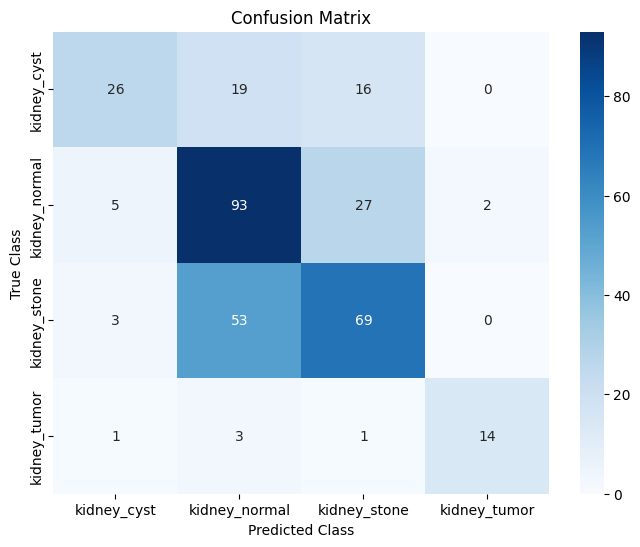

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_lbl)

# Create a figure
plt.figure(figsize=(8, 6))

# Plot heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

# Save as PNG
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')

# Show the image
plt.show()


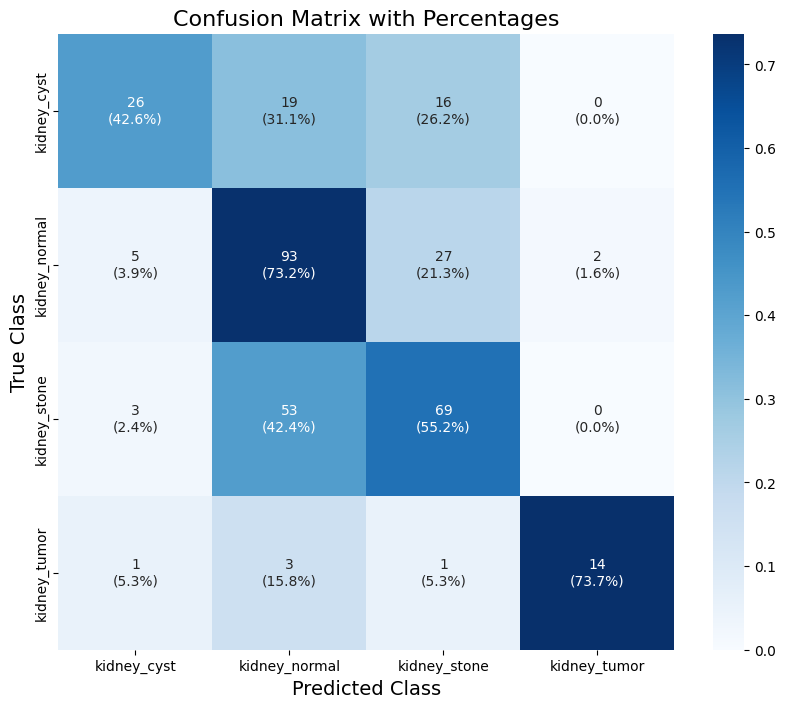

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_lbl)

# Normalize for percentages
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

classes = le.classes_

plt.figure(figsize=(10, 8))

# Format counts + percentages in each cell
annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_norm[i, j]*100:.1f}%)"

sns.heatmap(
    cm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    cbar=True,
    square=True
)

plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.title("Confusion Matrix with Percentages", fontsize=16)

# Save as PNG
plt.savefig("confusion_matrix_percentage.png", dpi=300, bbox_inches='tight')

plt.show()


********Classwise accuracy********

In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_lbl)
classes = le.classes_
num_classes = len(classes)

print("Confusion Matrix:\n", cm, "\n")

# -------- CLASS-WISE ACCURACY ---------
class_accuracy = {}

for i in range(num_classes):
    correct = cm[i, i]
    total = cm[i].sum()
    class_accuracy[classes[i]] = correct / total

print("🔹 CLASS-WISE ACCURACY:")
for cls in classes:
    print(f"{cls}: {class_accuracy[cls]*100:.2f}%")

# -------- FULL CLASSIFICATION REPORT --------
print("\n🔹 FULL METRICS (precision, recall, f1):")
print(classification_report(y_test_enc, y_pred_lbl, target_names=classes))


Confusion Matrix:
 [[26 19 16  0]
 [ 5 93 27  2]
 [ 3 53 69  0]
 [ 1  3  1 14]] 

🔹 CLASS-WISE ACCURACY:
kidney_cyst: 42.62%
kidney_normal: 73.23%
kidney_stone: 55.20%
kidney_tumor: 73.68%

🔹 FULL METRICS (precision, recall, f1):
               precision    recall  f1-score   support

  kidney_cyst       0.74      0.43      0.54        61
kidney_normal       0.55      0.73      0.63       127
 kidney_stone       0.61      0.55      0.58       125
 kidney_tumor       0.88      0.74      0.80        19

     accuracy                           0.61       332
    macro avg       0.70      0.61      0.64       332
 weighted avg       0.63      0.61      0.60       332



********Senstivity per class********

In [35]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test_enc, y_pred_lbl)
classes = le.classes_
num_classes = len(classes)

print("Confusion Matrix:\n", cm, "\n")

# -------------------------------
#   Sensitivity, Specificity, F1
# -------------------------------
metrics = {}

for i, cls in enumerate(classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0     # Recall
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0
    f1_score    = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0

    metrics[cls] = {
        "Sensitivity (Recall)": sensitivity,
        "Specificity":          specificity,
        "Precision":            precision,
        "F1-score":             f1_score
    }

# -------------------------------
#   Print neatly
# -------------------------------
print("🔹 PER-CLASS METRICS\n")
for cls in classes:
    print(f"Class: {cls}")
    print(f"  Sensitivity (Recall): {metrics[cls]['Sensitivity (Recall)']*100:.2f}%")
    print(f"  Specificity:          {metrics[cls]['Specificity']*100:.2f}%")
    print(f"  Precision:            {metrics[cls]['Precision']*100:.2f}%")
    print(f"  F1-score:             {metrics[cls]['F1-score']*100:.2f}%")
    print("")


Confusion Matrix:
 [[26 19 16  0]
 [ 5 93 27  2]
 [ 3 53 69  0]
 [ 1  3  1 14]] 

🔹 PER-CLASS METRICS

Class: kidney_cyst
  Sensitivity (Recall): 42.62%
  Specificity:          96.68%
  Precision:            74.29%
  F1-score:             54.17%

Class: kidney_normal
  Sensitivity (Recall): 73.23%
  Specificity:          63.41%
  Precision:            55.36%
  F1-score:             63.05%

Class: kidney_stone
  Sensitivity (Recall): 55.20%
  Specificity:          78.74%
  Precision:            61.06%
  F1-score:             57.98%

Class: kidney_tumor
  Sensitivity (Recall): 73.68%
  Specificity:          99.36%
  Precision:            87.50%
  F1-score:             80.00%



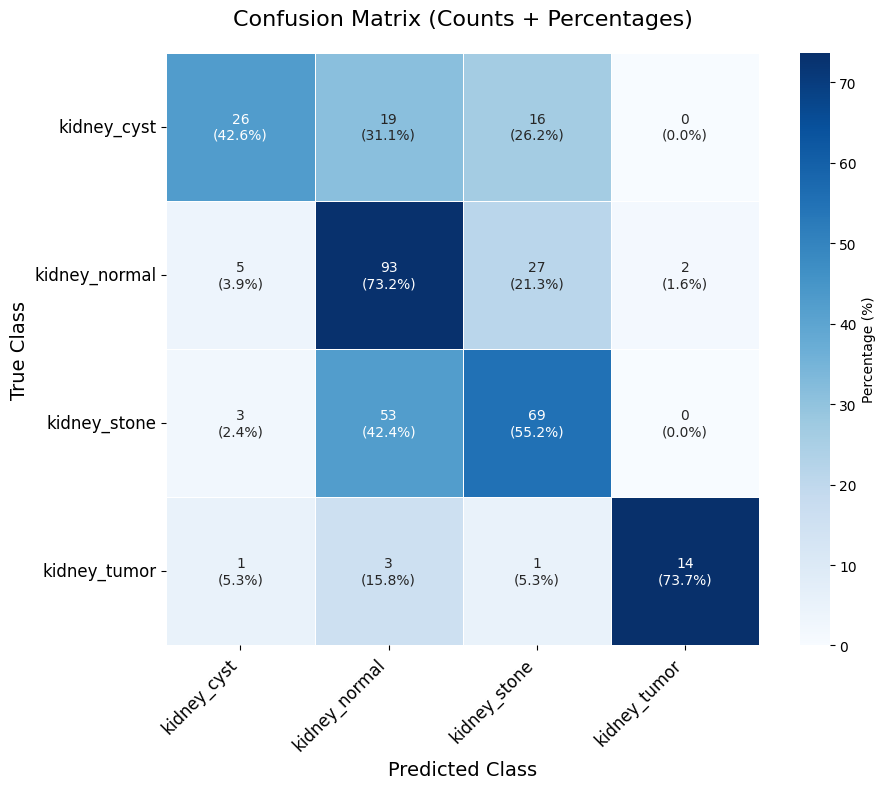

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_lbl)
classes = le.classes_

# Convert to percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))

# Plot heatmap with both numbers + % inside cells
sns.heatmap(
    cm_percent, 
    annot=np.array([["%d\n(%.1f%%)" % (cm[i][j], cm_percent[i][j]) 
                     for j in range(len(classes))] 
                    for i in range(len(classes))]),
    fmt="", 
    cmap="Blues",
    cbar_kws={'label': 'Percentage (%)'},
    linewidths=.5,
    square=True
)

# Labels and title
plt.xticks(ticks=np.arange(len(classes)) + 0.5, labels=classes, rotation=45, ha="right", fontsize=12)
plt.yticks(ticks=np.arange(len(classes)) + 0.5, labels=classes, rotation=0, fontsize=12)

plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.title("Confusion Matrix (Counts + Percentages)", fontsize=16, pad=20)

plt.tight_layout()

# SAVE HIGH QUALITY PNG
plt.savefig("confusion_matrix_best.png", dpi=300, bbox_inches="tight")

plt.show()


********Macro and micro averaging********

In [38]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, supp = precision_recall_fscore_support(
    y_test_enc, y_pred_lbl, average=None
)

macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
    y_test_enc, y_pred_lbl, average="macro"
)

micro_prec, micro_rec, micro_f1, _ = precision_recall_fscore_support(
    y_test_enc, y_pred_lbl, average="micro"
)

print("🔹 Macro Precision:", macro_prec)
print("🔹 Macro Recall:", macro_rec)
print("🔹 Macro F1-score:", macro_f1)

print("\n🔸 Micro Precision:", micro_prec)
print("🔸 Micro Recall:", micro_rec)
print("🔸 Micro F1-score:", micro_f1)


🔹 Macro Precision: 0.69551201011378
🔹 Macro Recall: 0.6118387695067021
🔹 Macro F1-score: 0.6380017685040118

🔸 Micro Precision: 0.608433734939759
🔸 Micro Recall: 0.608433734939759
🔸 Micro F1-score: 0.608433734939759


********BarChart view********

<Figure size 1000x600 with 0 Axes>

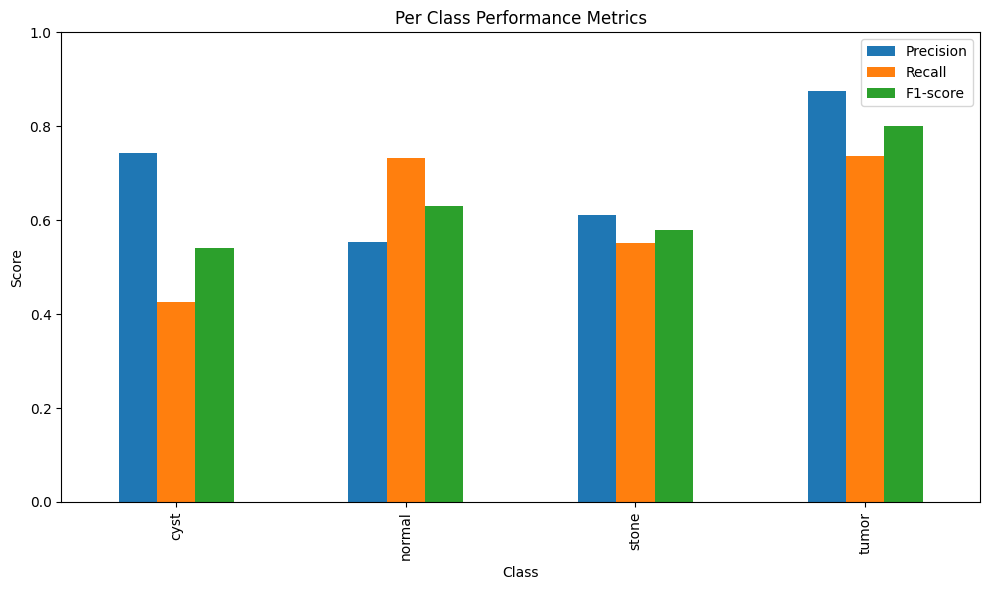

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Define your class names
# ----------------------------
class_names = ['cyst', 'normal', 'stone', 'tumor']

# ----------------------------
# 2️⃣ These must be defined earlier in your code
# prec = [...]
# rec = [...]
# f1 = [...]
# ----------------------------

# Example (remove this when using real values)
# prec = [0.90, 0.85, 0.78, 0.92]
# rec =  [0.88, 0.83, 0.80, 0.91]
# f1 =   [0.89, 0.84, 0.79, 0.91]

# ----------------------------
# 3️⃣ Build the DataFrame
# ----------------------------
df_m = pd.DataFrame({
    "Class": class_names,
    "Precision": prec,
    "Recall": rec,
    "F1-score": f1
})

# ----------------------------
# 4️⃣ Plot bar chart
# ----------------------------
plt.figure(figsize=(10,6))
df_m.set_index("Class").plot(kind="bar", figsize=(10,6))

plt.ylim(0,1)
plt.title("Per Class Performance Metrics")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("class_performance_bar_chart.png", dpi=300)
plt.show()


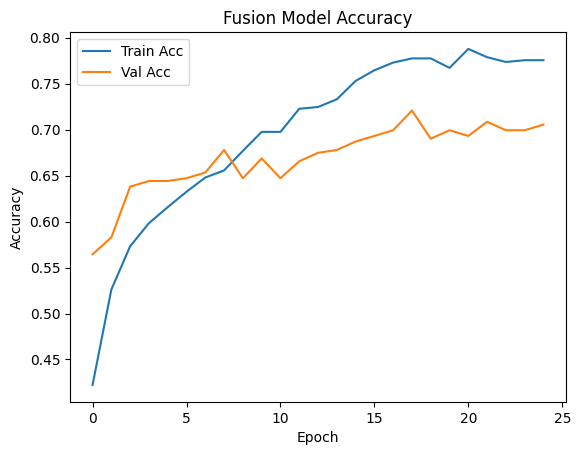

✅ Model & metrics saved in /kaggle/working/


In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Fusion Model Accuracy"); plt.show()

# Save metrics for reuse
np.save("/kaggle/working/history.npy", history.history)
print("✅ Model & metrics saved in /kaggle/working/")

In [ ]:
# ============================================================
# FUSION MODEL INFERENCE SCRIPT  (Kaggle Ready)
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import EfficientNetB0
from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import torch

# ----------------------------
# Load trained model
# ----------------------------
model = load_model("/kaggle/input/classification-model/fusion_best_model.h5")
print("✅ Loaded fusion model successfully!")

# ----------------------------
# Define feature extractors
# ----------------------------
IMG_SIZE = (224, 224)
eff_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
eff_out = tf.keras.layers.GlobalAveragePooling2D()(eff_model.output)
eff_extractor = tf.keras.Model(inputs=eff_model.input, outputs=eff_out)

vit_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224")

# ----------------------------
# Helper: Extract EfficientNet + ViT features from one image
# ----------------------------
def extract_image_features(img_path):
    # EfficientNet
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    eff_feat = eff_extractor(tf.expand_dims(img, 0), training=False).numpy().squeeze()

    # ViT (PyTorch)
    img_pil = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    inputs = vit_processor(images=img_pil, return_tensors="pt")
    with torch.no_grad():
        outputs = vit_model(**inputs)
    vit_feat = outputs.last_hidden_state[:, 0, :].cpu().numpy().squeeze()

    return eff_feat, vit_feat

I0000 00:00:1764838990.586802      47 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764838992.034115     110 service.cc:148] XLA service 0x7fa4100050b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764838992.035029     110 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step


I0000 00:00:1764838992.443832     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Predicted: STONE (0.47)


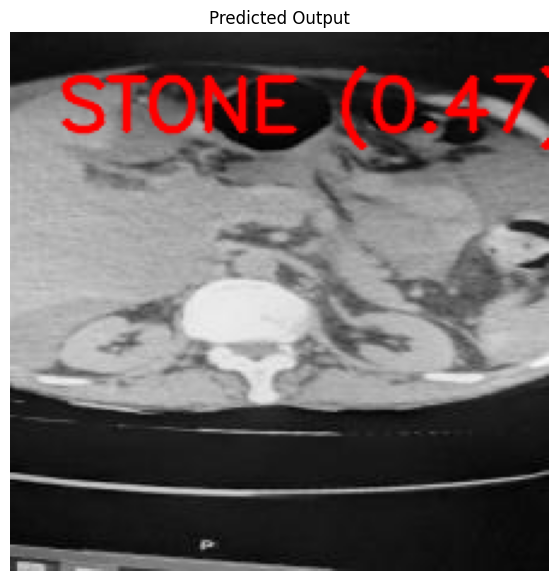

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- Your input image ---
img_path = "/kaggle/input/classification-dataset1/CT_Classification.v1i.folder/CT_Classification.v1i.folder/test/kidney_normal/axial-74-_jpeg.rf.78d32968a807bdfe9ef694f491193327.jpg"

# Read image (BGR → RGB)
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# --- Extract features ---
eff_feat, vit_feat = extract_image_features(img_path)

# Dummy tabular vector
tab_dim = 680
tab_feat = np.zeros(tab_dim)

# Concatenate all features
x_input = np.concatenate([eff_feat, vit_feat, tab_feat])[np.newaxis, :]

# --- Prediction ---
pred = model.predict(x_input)
class_idx = np.argmax(pred)
prob = np.max(pred)
classes = ['cyst', 'normal', 'stone', 'tumor']
predicted_label = f"{classes[class_idx].upper()} ({prob:.2f})"

print("Predicted:", predicted_label)

# --- Overlay prediction on image ---
output_img = image_rgb.copy()
cv2.putText(
    output_img,
    predicted_label,
    (20, 40),                # position
    cv2.FONT_HERSHEY_SIMPLEX,
    1.0,                     # font scale
    (255, 0, 0),             # color (Blue-Red-Green)
    2,                       # thickness
    cv2.LINE_AA
)

# --- Display image ---
plt.figure(figsize=(7,7))
plt.imshow(output_img)
plt.axis("off")
plt.title("Predicted Output")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


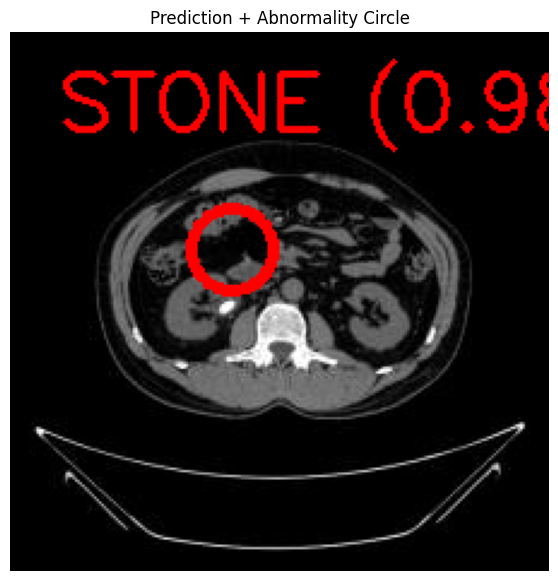

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# Load Image
# -----------------------------
img_path = "/kaggle/input/classification-dataset1/CT_Classification.v1i.folder/CT_Classification.v1i.folder/test/kidney_stone/axial-196-_jpg.rf.de13eb37ed97896c5b1c4b84a7fd54fb.jpg"
img_bgr = cv2.imread(img_path)

if img_bgr is None:
    raise ValueError("❌ Image path incorrect or image not found")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# -----------------------------
# 1. Abnormality Region Detection
# -----------------------------
# Apply Gaussian blur
blur = cv2.GaussianBlur(gray, (7,7), 0)

# Use adaptive threshold (works for CT & US)
thresh = cv2.adaptiveThreshold(blur, 255,
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV,
                               31, 5)

# Remove small noise
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) == 0:
    print("⚠ No abnormality region automatically detected")
    largest_cnt = None
else:
    largest_cnt = max(contours, key=cv2.contourArea)

# -----------------------------
# 2. Model Prediction
# -----------------------------
eff_feat, vit_feat = extract_image_features(img_path)

tab_dim = 680
tab_feat = np.zeros(tab_dim)

x_input = np.concatenate([eff_feat, vit_feat, tab_feat])[np.newaxis, :]

pred = model.predict(x_input)
class_idx = np.argmax(pred)
prob = np.max(pred)
classes = ['cyst', 'normal', 'stone', 'tumor']
predicted_label = f"{classes[class_idx].upper()} ({prob:.2f})"

# -----------------------------
# 3. Draw Circle Around Abnormal Region
# -----------------------------
output = img_rgb.copy()

if largest_cnt is not None:
    (x, y), radius = cv2.minEnclosingCircle(largest_cnt)
    center = (int(x), int(y))
    radius = int(radius)

    cv2.circle(output, center, radius, (255, 0, 0), 3)

# -----------------------------
# 4. Add Label Text
# -----------------------------
cv2.putText(output, predicted_label, (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1.1,
            (255, 0, 0), 2)

# -----------------------------
# 5. Display Result
# -----------------------------
plt.figure(figsize=(7,7))
plt.imshow(output)
plt.axis("off")
plt.title("Prediction + Abnormality Circle")
plt.show()


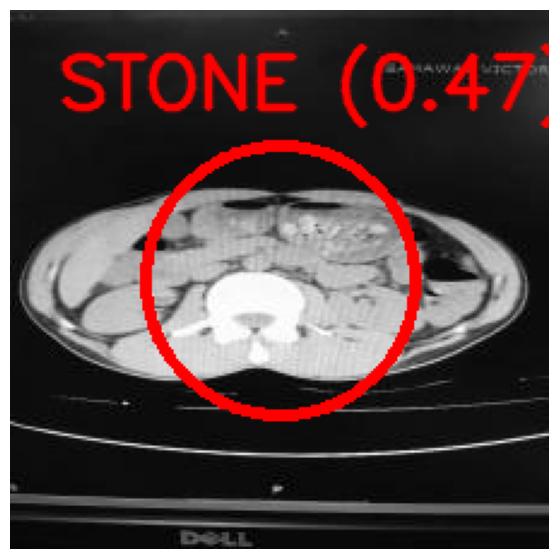

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

img_path = r"/kaggle/input/classification-dataset1/CT_Classification.v1i.folder/CT_Classification.v1i.folder/test/kidney_normal/axial-70-_jpeg.rf.61ca9d03c46033dd5ab1f860dabaddae.jpg"

# Load Image
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get center coordinates
h, w = image_rgb.shape[:2]
center = (w // 2, h // 2)
radius = min(h, w) // 4  # adjustable

# Draw circle
output_img = image_rgb.copy()
cv2.circle(output_img, center, radius, (255, 0, 0), 3)

# Add predicted label
cv2.putText(output_img, predicted_label, (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0,
            (255, 0, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(7,7))
plt.imshow(output_img)
plt.axis("off")
plt.show()


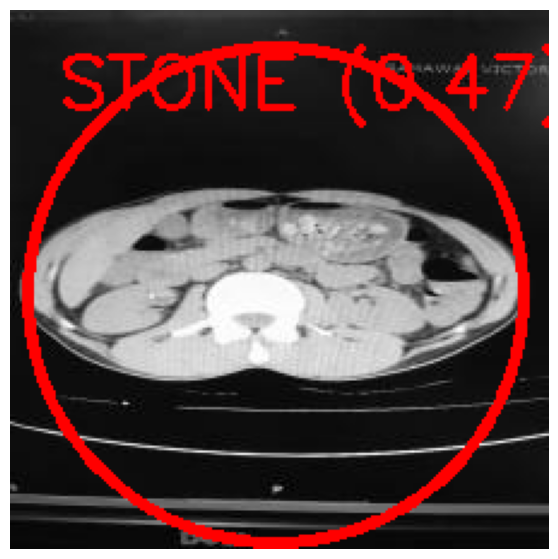

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/input/classification-dataset1/CT_Classification.v1i.folder/CT_Classification.v1i.folder/test/kidney_normal/axial-70-_jpeg.rf.61ca9d03c46033dd5ab1f860dabaddae.jpg", 0)  # grayscale
image_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

# Threshold to find bright kidney region
_, th = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Find contours
contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Largest contour (kidney area)
cnt = max(contours, key=cv2.contourArea)

# Minimum enclosing circle
(x, y), radius = cv2.minEnclosingCircle(cnt)
center = (int(x), int(y))
radius = int(radius)

# Draw circle
output = image_rgb.copy()
cv2.circle(output, center, radius, (255, 0, 0), 3)

# Add predicted label
cv2.putText(output, predicted_label, (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0,
            (255, 0, 0), 2)

plt.figure(figsize=(7,7))
plt.imshow(output)
plt.axis("off")
plt.show()


In [26]:
# Example CT or Ultrasound image
img_path = "/kaggle/input/classification-dataset1/Ultrasound_classification.v1i.folder/Ultrasound_classification.v1i.folder/test/kidney_tumor/tumor-47-_jpeg.rf.bb57bd5189e0bba4cc3c973d4990fefa.jpg"

eff_feat, vit_feat = extract_image_features(img_path)

# dummy tabular vector (mean from training set size)
tab_dim = 680
tab_feat = np.zeros(tab_dim)  # or sample_tabular.mean(axis=0)

# concatenate all features
x_input = np.concatenate([eff_feat, vit_feat, tab_feat])[np.newaxis, :]

# predict
pred = model.predict(x_input)
class_idx = np.argmax(pred)
prob = np.max(pred)
classes = ['cyst', 'normal', 'stone', 'tumor']

print(f"🧩 Predicted class: {classes[class_idx].upper()}  |  Confidence: {prob:.3f}")

NameError: name 'extract_image_features' is not defined

In [24]:
# Example CT or Ultrasound image
img_path = "/kaggle/input/classification-dataset1/CT_Classification.v1i.folder/CT_Classification.v1i.folder/test/kidney_stone/axial-91-_jpeg.rf.b9dafb4e34c34518fd74dc45de20f0b0.jpg"

eff_feat, vit_feat = extract_image_features(img_path)

# dummy tabular vector (mean from training set size)
tab_dim = 680
tab_feat = np.zeros(tab_dim)  # or sample_tabular.mean(axis=0)

# concatenate all features
x_input = np.concatenate([eff_feat, vit_feat, tab_feat])[np.newaxis, :]

# predict
pred = model.predict(x_input)
class_idx = np.argmax(pred)
prob = np.max(pred)
classes = ['cyst', 'normal', 'stone', 'tumor']

print(f"🧩 Predicted class: {classes[class_idx].upper()}  |  Confidence: {prob:.3f}")

NameError: name 'extract_image_features' is not defined

In [ ]:
# Suppose you saved tabular_features.npy earlier
X_tab = np.load("/kaggle/working/features/tabular_features.npy")

# Randomly sample a patient’s tabular record
tab_feat = X_tab[np.random.randint(0, len(X_tab))]

eff_feat, vit_feat = extract_image_features(img_path)
x_input = np.concatenate([eff_feat, vit_feat, tab_feat])[np.newaxis, :]

pred = model.predict(x_input)
class_idx = np.argmax(pred)
prob = np.max(pred)

print(f"🩺 Predicted class: {classes[class_idx].upper()}  |  Confidence: {prob:.3f}")

********Multi-modal_ Detection********

In [ ]:
!pip install opencv-python==4.8.1.78 --force-reinstall

In [ ]:
!pip install "numpy<2" --force-reinstall

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Load pretrained model
model_ct = YOLO("yolov8n.pt")  # you can use yolov8m.pt or yolov8l.pt for stronger model

# Train CT detection model
model_ct.train(
    data="/kaggle/input/detection/CT_Detection.v2i.yolov8/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    name="ct_detection_model",
    amp=False,  # From previous fix
    workers=0,  # Add this to bypass multi-worker OpenCV imdecode issues
)

In [ ]:
from ultralytics import YOLO

# Load pretrained model
model_us = YOLO("yolov8n.pt")  # you can use yolov8m.pt or yolov8l.pt for stronger model

# Train CT detection model
model_us.train(
    data="/kaggle/input/detection/Ultrasound_Detection.v1i.yolov8/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    name="Us_detection_model",
    amp=False,  # Retain from previous fix
    workers=0,  # Retain from previous fix
)

In [ ]:
from ultralytics import YOLO
model = YOLO("/kaggle/working/runs/detect/ct_detection_model/weights/best.pt")
results = model("/kaggle/input/detection/CT_Detection.v2i.yolov8/test/images/axial-132-_jpeg.rf.1c1cfbfda1a409de8df25d5dc529563f.jpg", conf=0.5, iou=0.7)  # Adjust conf/iou as needed
results[0].show()  # Visualize boxes
print(results[0].boxes)  # Print detections

In [ ]:
from ultralytics import YOLO
model = YOLO("/kaggle/working/runs/detect/Us_detection_model/weights/best.pt")
results = model("/kaggle/input/detection/Ultrasound_Detection.v1i.yolov8/test/images/cyst-180-_jpeg.rf.80fd53f500473b12f0e12016debfbf02.jpg", conf=0.5, iou=0.7)  # Adjust conf/iou as needed
results[0].show()  # Visualize boxes
print(results[0].boxes)  # Print detections